# PROJETO PRÁTICO – MINERAÇÃO DE DADOS

**Instituição:** Instituto Federal de Educação, Ciência e Tecnologia da Paraíba (IFPB)  
**Campus:** Campina Grande  
**Curso:** Bacharelado em Engenharia da Computação  
**Disciplina:** Mineração de Dados  
**Professor:** Marcelo José Siqueira Coutinho de Almeida  

---

## Título do Projeto
**Classificação de Tumores de Mama Utilizando Técnicas de Aprendizado de Máquina**

**Autores:** Thiago Barbosa de Araújo, Kevin Ryan Soares  

---

# Importação Dados

In [1]:
pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Bibliotecas

In [3]:
# 1. Manipulação e Análise de Dados
import pandas as pd
import math

# 2. Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Pré-processamento e Divisão de Dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 4. Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 5. Métricas de Avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    accuracy_score
)

# 1. Análise Exploratória dos Dados

## Criação do Dataset

In [4]:
# Criar DataFrame
df = pd.DataFrame()

# Adicionar as features
for col in X.columns:
    df[col] = X[col]

# Adicionar o target
df['diagnostico'] = y

print("=== DATAFRAME CRIADO ===")
print(f"Shape: {df.shape}")

df.head()

=== DATAFRAME CRIADO ===
Shape: (569, 31)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


## Tipos dos dados

In [5]:
# Tipos de Dados
df.dtypes

,0
radius1,float64
texture1,float64
perimeter1,float64
area1,float64
smoothness1,float64
compactness1,float64
concavity1,float64
concave_points1,float64
symmetry1,float64
fractal_dimension1,float64


## Convertendo Variavel alvo para tipo númerico

In [6]:
df['diagnostico'] = df['diagnostico'].map({'M': 1, 'B': 0})

In [7]:
df.diagnostico.info()

<class 'pandas.core.series.Series'>
RangeIndex: 569 entries, 0 to 568
Series name: diagnostico
Non-Null Count  Dtype
--------------  -----
569 non-null    int64
dtypes: int64(1)
memory usage: 4.6 KB


## Distribuição da Variavel target (Diagnostico)

diagnostico
0    357
1    212
Name: count, dtype: int64


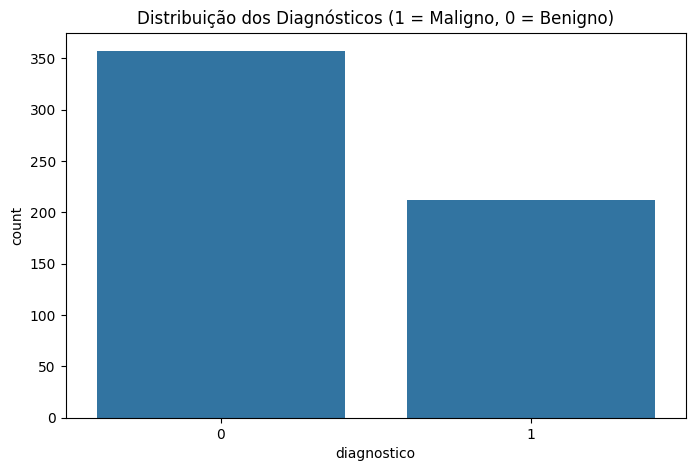

In [8]:
# Contagem de valores
print(df['diagnostico'].value_counts())

# Visualização gráfica
plt.figure(figsize=(8, 5))
sns.countplot(x='diagnostico', data=df)
plt.title('Distribuição dos Diagnósticos (1 = Maligno, 0 = Benigno)')
plt.show()

## Estatisticas das Variaveis Númericas

In [9]:
df.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture1,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter1,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area1,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness1,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity1,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points1,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry1,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## Correlação dos atributos com a variavel alvo

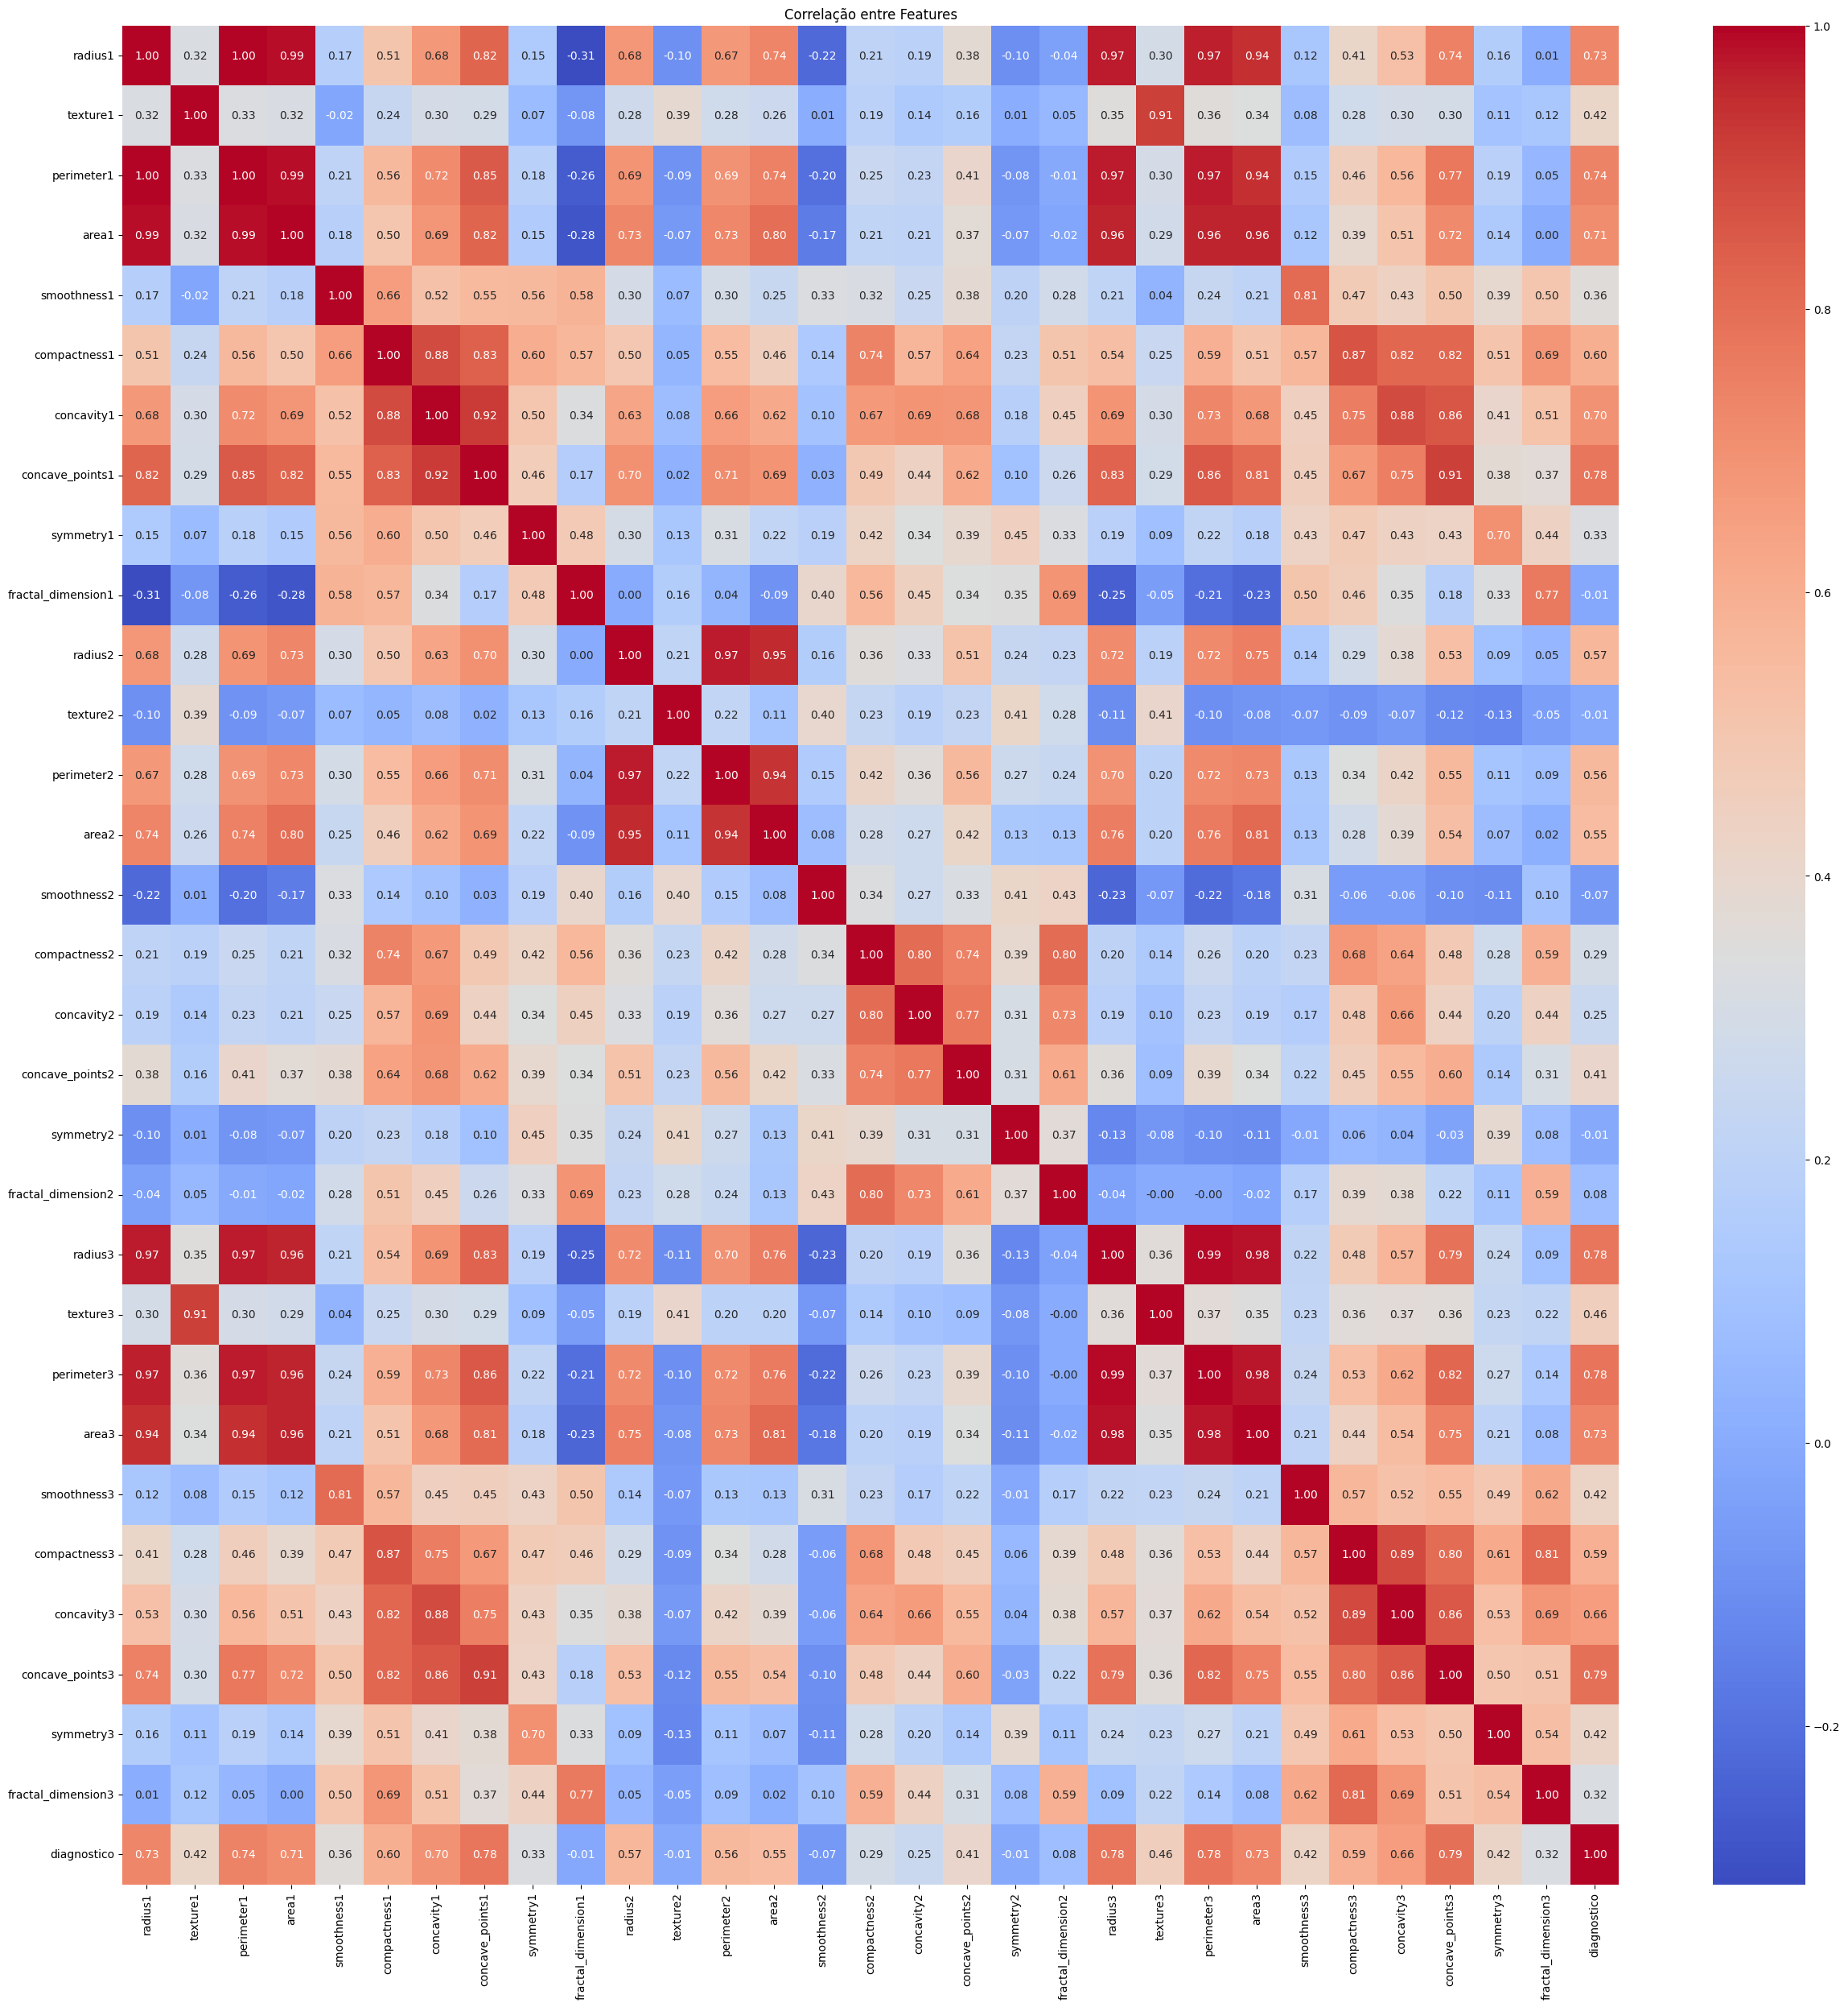

In [10]:
# Mapa de calor de correlação
plt.figure(figsize=(30, 30))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre Features')
plt.show()

In [11]:
corr_target = df.corr()['diagnostico'].sort_values(ascending=False)
print(corr_target)

diagnostico           1.000000
concave_points3       0.793566
perimeter3            0.782914
concave_points1       0.776614
radius3               0.776454
perimeter1            0.742636
area3                 0.733825
radius1               0.730029
area1                 0.708984
concavity1            0.696360
concavity3            0.659610
compactness1          0.596534
compactness3          0.590998
radius2               0.567134
perimeter2            0.556141
area2                 0.548236
texture3              0.456903
smoothness3           0.421465
symmetry3             0.416294
texture1              0.415185
concave_points2       0.408042
smoothness1           0.358560
symmetry1             0.330499
fractal_dimension3    0.323872
compactness2          0.292999
concavity2            0.253730
fractal_dimension2    0.077972
symmetry2            -0.006522
texture2             -0.008303
fractal_dimension1   -0.012838
smoothness2          -0.067016
Name: diagnostico, dtype: float64


## Histogramas (distribuição das variáveis)

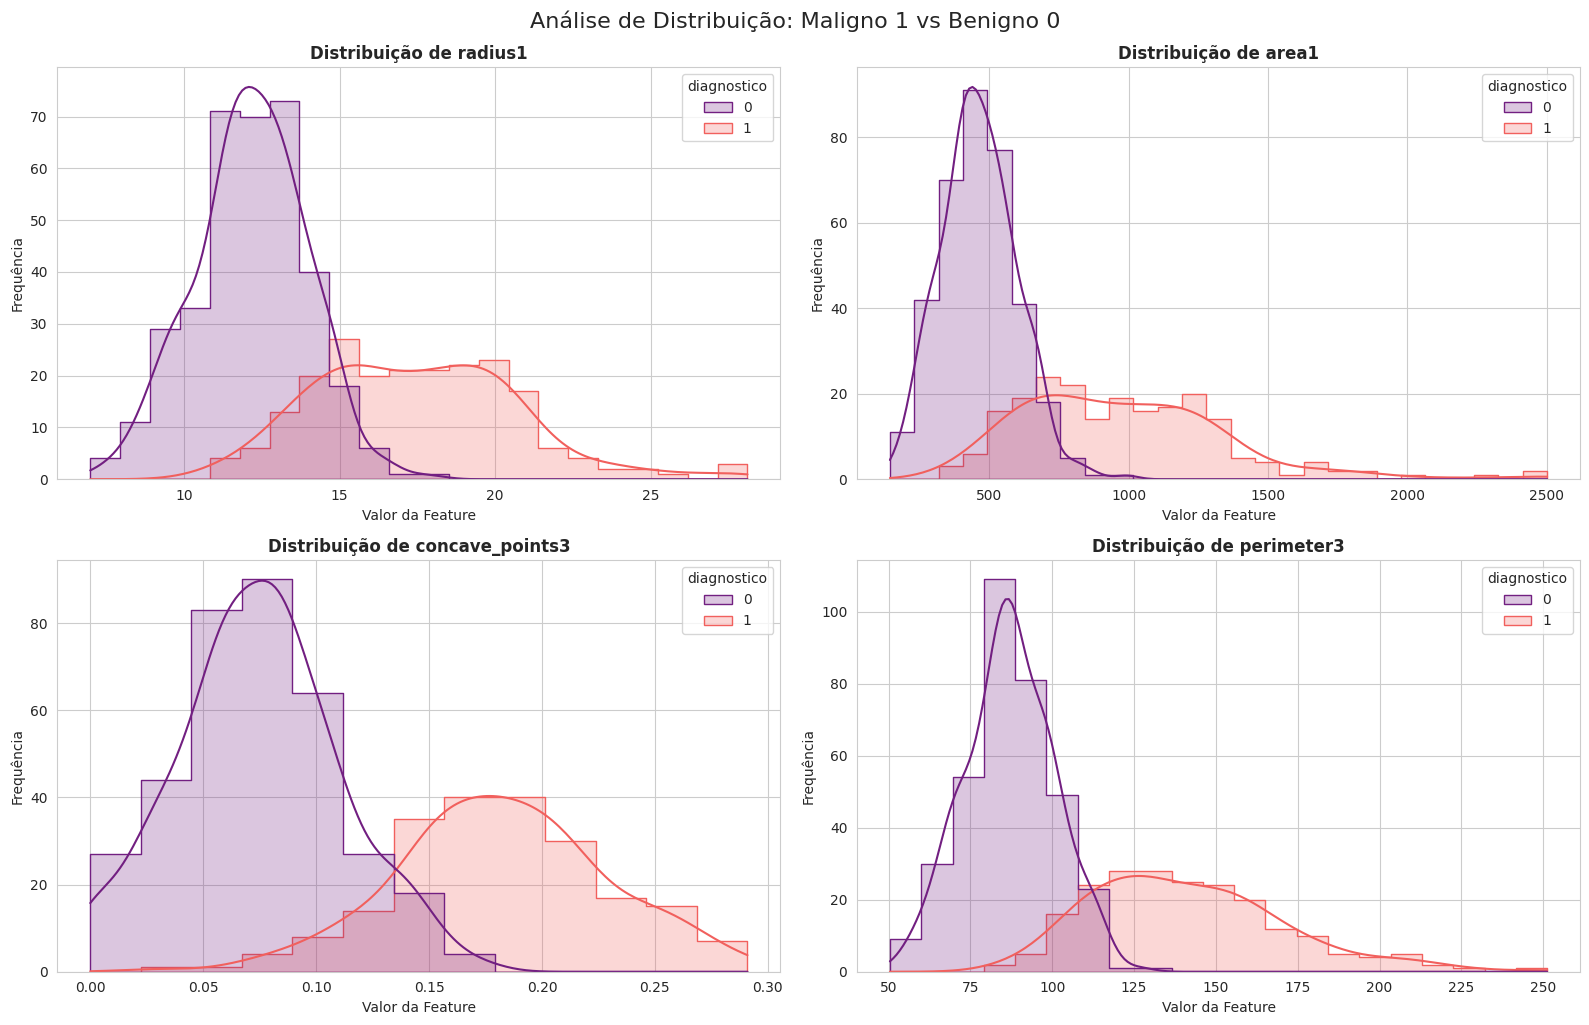

In [28]:
# Lista das features para os histogramas
features_hist = ['radius1', 'area1', 'concave_points3', 'perimeter3']

# Criando a grade 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features_hist):
    sns.histplot(
        data=df,
        x=col,
        hue='diagnostico',
        kde=True,
        ax=axes[i],
        palette='magma',
        element="step"
    )
    axes[i].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Valor da Feature')
    axes[i].set_ylabel('Frequência')

plt.tight_layout()
plt.suptitle('Análise de Distribuição: Maligno 1 vs Benigno 0', fontsize=16, y=1.02)
plt.show()

## Boxplot

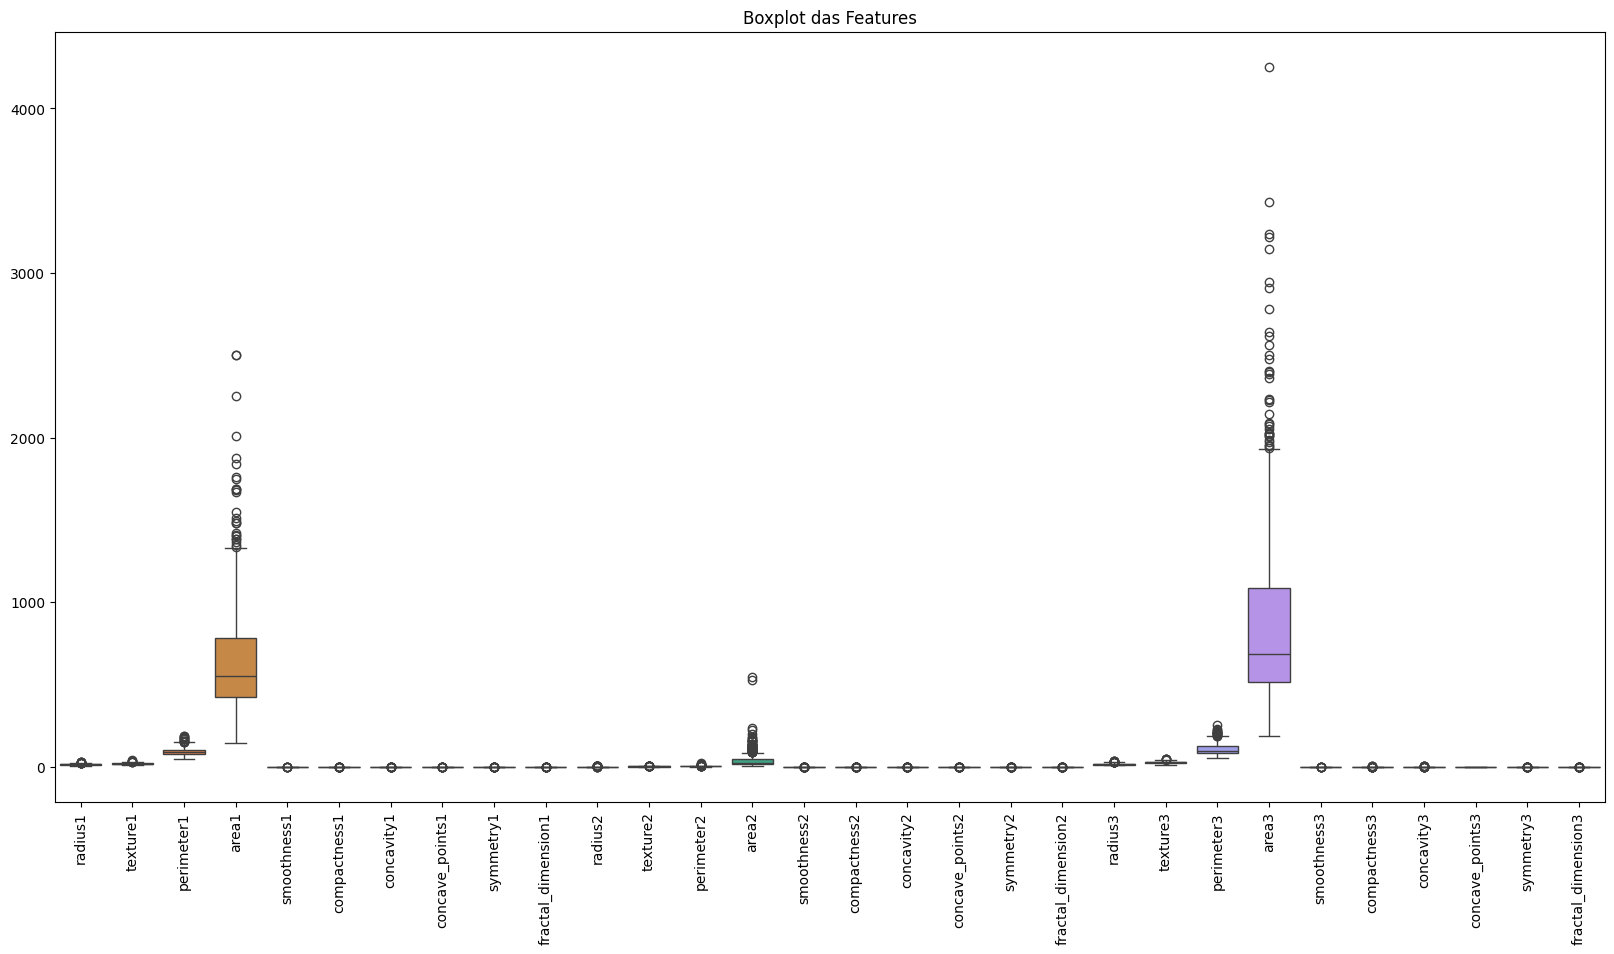

In [13]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=df.drop(columns=['diagnostico']))
plt.xticks(rotation=90)
plt.title('Boxplot das Features')
plt.show()

## Boxplot por classe

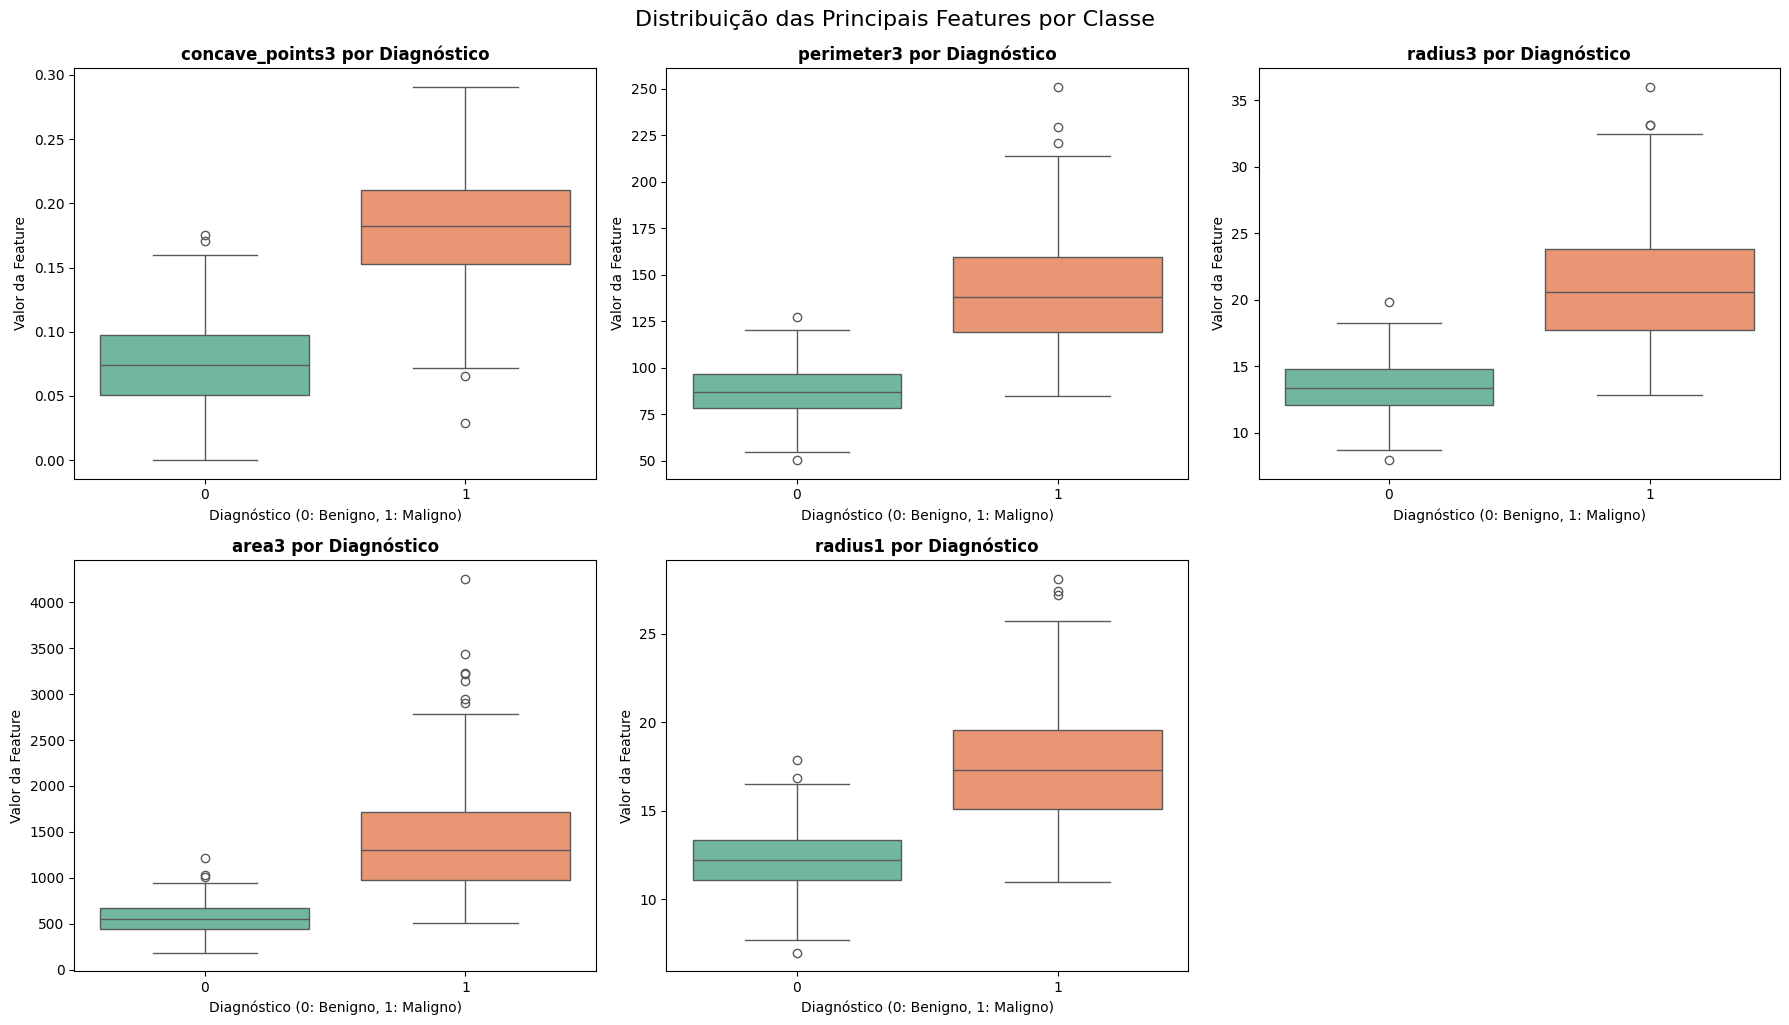

In [14]:
features_importantes = [
    'concave_points3', 'perimeter3', 'radius3',
    'area3', 'radius1'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_importantes):
    # Ajuste aqui: adicionamos hue='diagnostico' e legend=False
    sns.boxplot(
        x='diagnostico',
        y=col,
        data=df,
        ax=axes[i],
        palette='Set2',
        hue='diagnostico',
        legend=False
    )
    axes[i].set_title(f'{col} por Diagnóstico', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Diagnóstico (0: Benigno, 1: Maligno)')
    axes[i].set_ylabel('Valor da Feature')

fig.delaxes(axes[5])

plt.tight_layout()
plt.suptitle('Distribuição das Principais Features por Classe', fontsize=16, y=1.02)
plt.show()



> A visualização via Boxplot demonstra uma separação clara entre as classes para as features selecionadas, evidenciando que tumores malignos tendem a apresentar valores superiores de raio, área e pontos côncavos. Observa-se também a presença de valores atípicos (outliers), que justificam o uso de pré-processamento robusto nos modelos de classificação



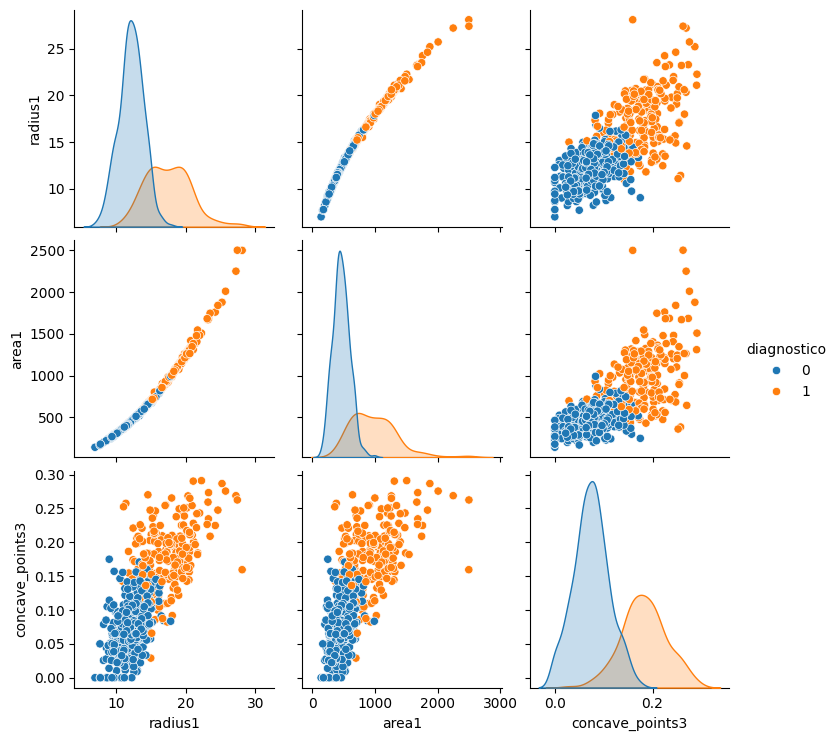

In [15]:
sns.pairplot(
    df[['diagnostico', 'radius1', 'area1', 'concave_points3']],
    hue='diagnostico'
)
plt.show()



> A matriz de dispersão (Pairplot) revela uma forte correlação positiva entre medidas de dimensão (raio e área) e destaca que a classe maligna tende a ocupar o espectro superior de todas as variáveis analisadas.



# 2. Preparação dos Dados

## Valores Ausentes

In [16]:
ausentes = df.isnull().sum()
print(ausentes)

radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
diagnostico           0
dtype: int64


## Separando Variaveis que tem maior peso para a previsão do diagnostico

PONTO DE CORTE: correlação > 0.6
Variáveis selecionadas: 10 de 30


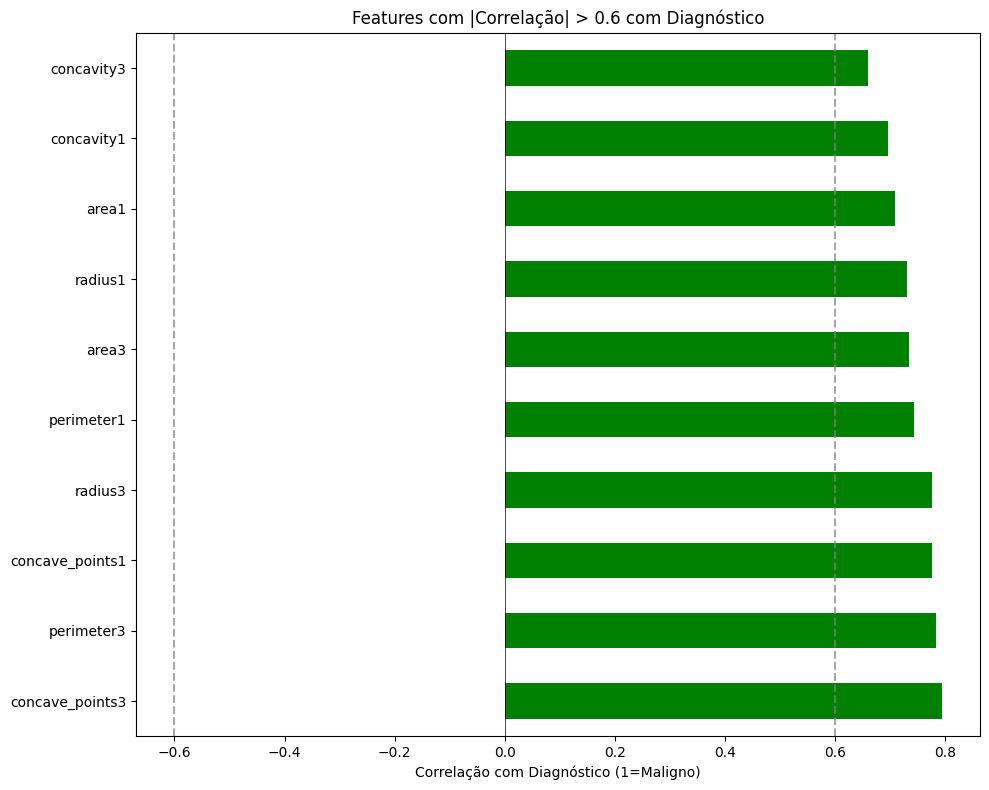

Dataset reduzido de 31 para 11 colunas

Verificando se a separação se mantém:


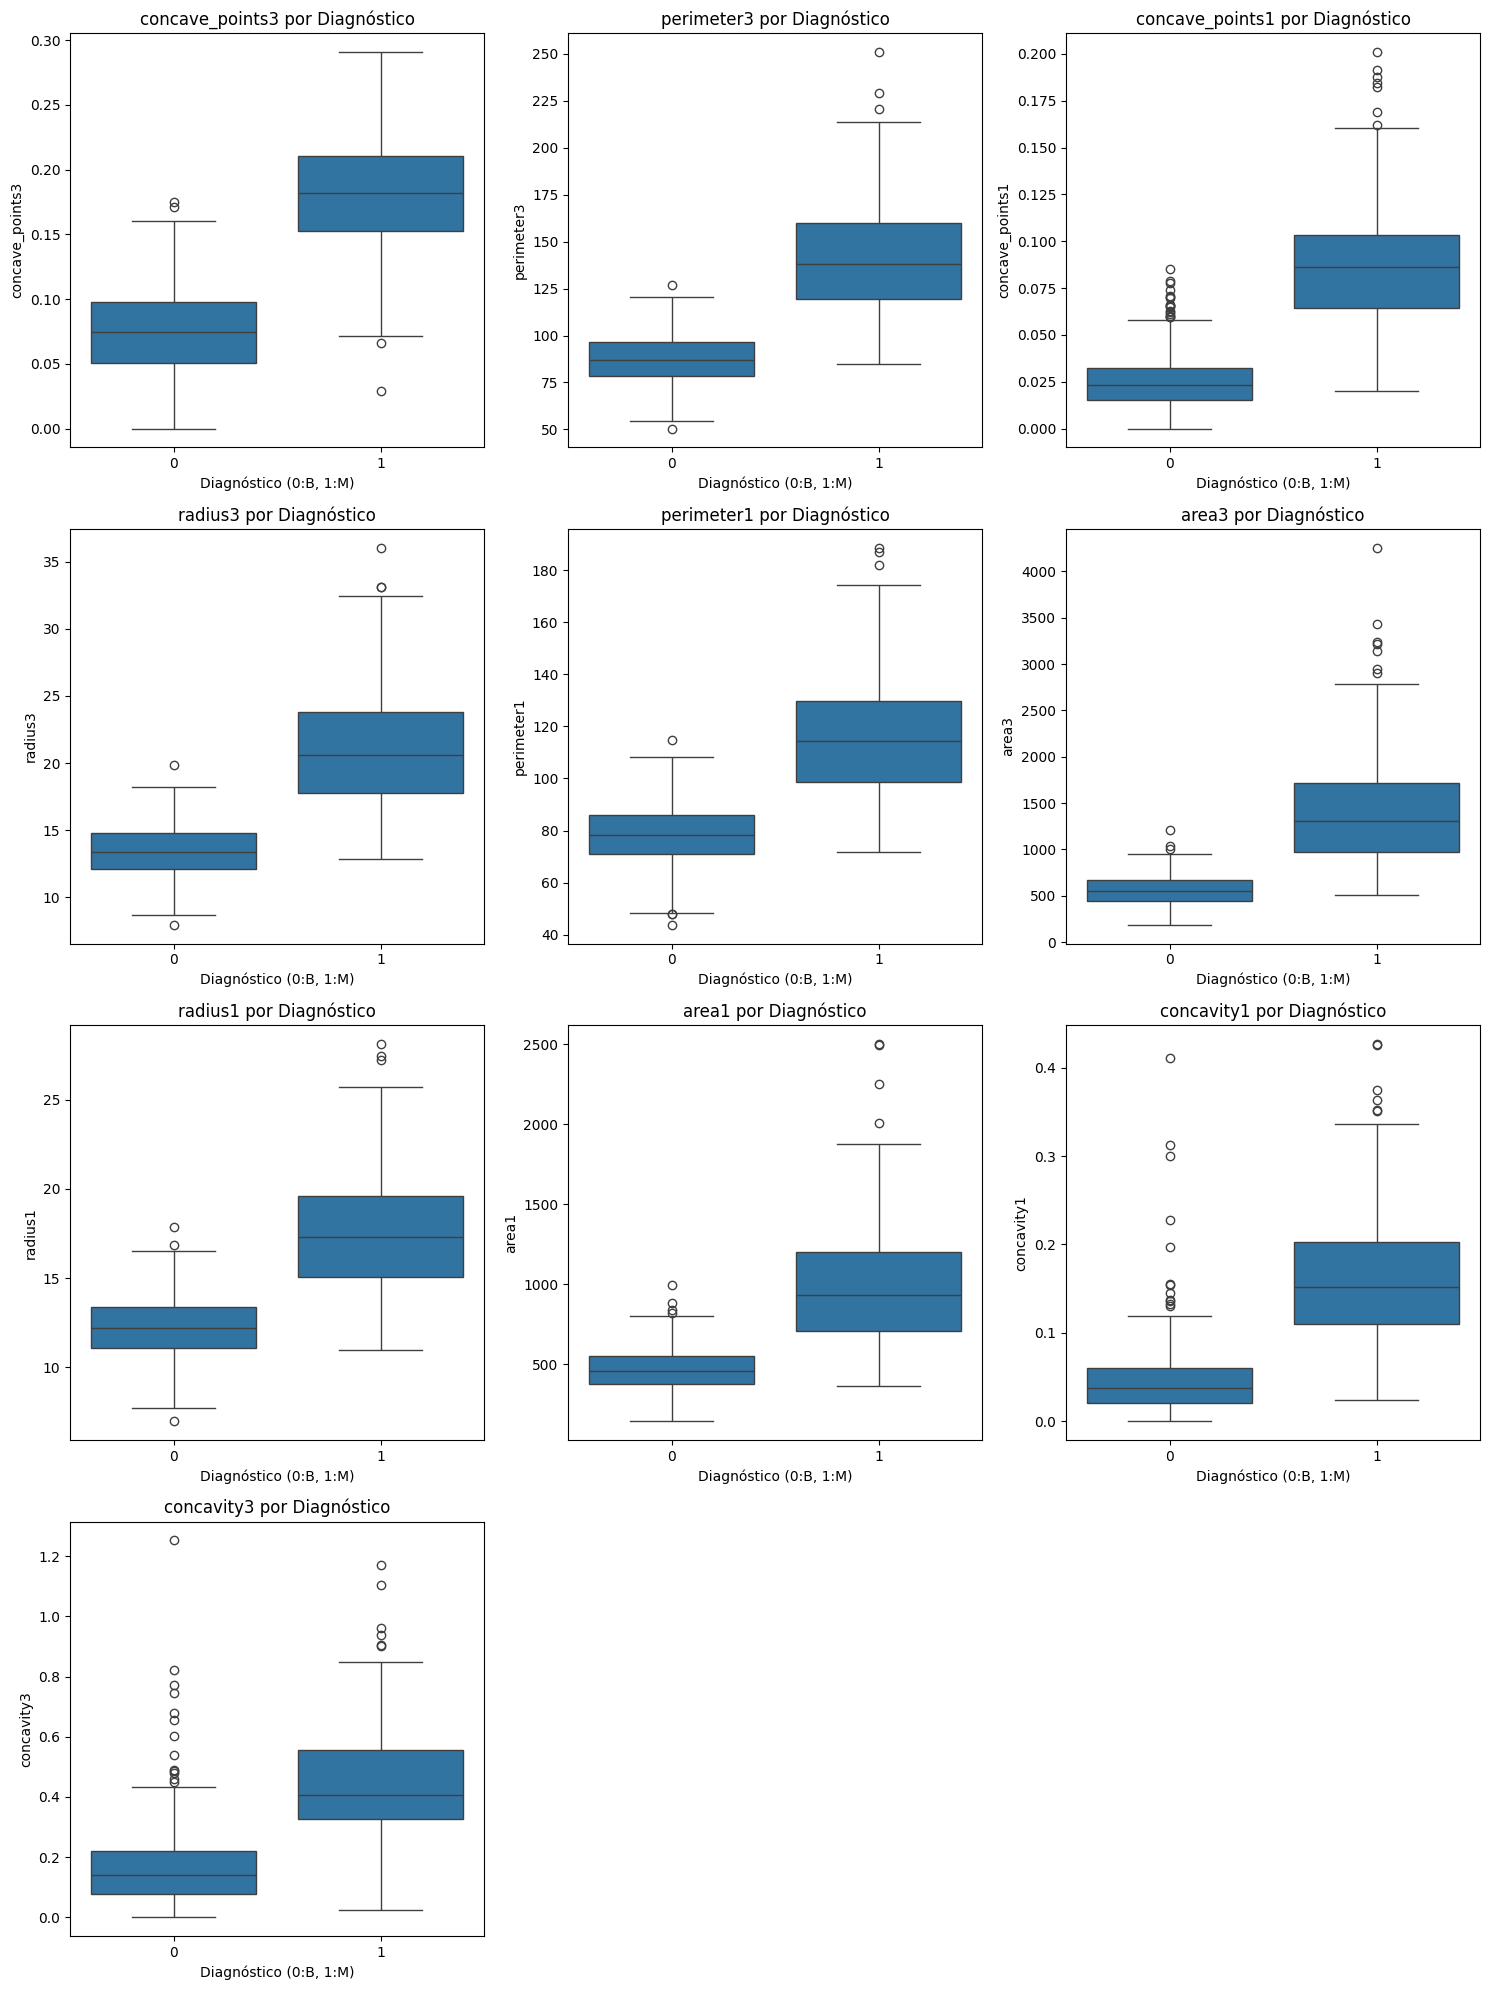

In [17]:
# Calcular correlações
correlacoes = df.corr()['diagnostico'].drop('diagnostico').sort_values(key=abs, ascending=False)

# Ponto de corte
corte = 0.6

# Selecionar principais
importantes = correlacoes[abs(correlacoes) > corte].index.tolist()

print(f"PONTO DE CORTE: correlação > {corte}")
print(f"Variáveis selecionadas: {len(importantes)} de {len(correlacoes)}")

# Visualizar as correlações
plt.figure(figsize=(10, 8))
top_correlacoes = correlacoes[abs(correlacoes) > corte]
colors = ['red' if x < 0 else 'green' for x in top_correlacoes]
top_correlacoes.plot(kind='barh', color=colors)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.axvline(x=corte, color='gray', linestyle='--', alpha=0.7)
plt.axvline(x=-corte, color='gray', linestyle='--', alpha=0.7)
plt.title(f'Features com |Correlação| > {corte} com Diagnóstico')
plt.xlabel('Correlação com Diagnóstico (1=Maligno)')
plt.tight_layout()
plt.show()

# Criar DataFrame reduzido
df_importante = df[['diagnostico'] + importantes]
print(f"Dataset reduzido de {df.shape[1]} para {df_importante.shape[1]} colunas")

# Verificar se a separação ainda é boa com apenas essas features
print("\nVerificando se a separação se mantém:")

# Configurações da grade
cols = 3  # Número de colunas na matriz
rows = math.ceil(len(importantes) / cols) # Calcula as linhas necessárias

# Cria a figura principal
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten() # Transforma a matriz de eixos em uma lista simples para iterar

for i, var in enumerate(importantes):
    sns.boxplot(x='diagnostico', y=var, data=df, ax=axes[i])
    axes[i].set_title(f'{var} por Diagnóstico')
    axes[i].set_xlabel('Diagnóstico (0:B, 1:M)')

# Remove eixos vazios (caso o número de variáveis não seja múltiplo de 'cols')
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [18]:
df_importante.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   diagnostico      569 non-null    int64  
 1   concave_points3  569 non-null    float64
 2   perimeter3       569 non-null    float64
 3   concave_points1  569 non-null    float64
 4   radius3          569 non-null    float64
 5   perimeter1       569 non-null    float64
 6   area3            569 non-null    float64
 7   radius1          569 non-null    float64
 8   area1            569 non-null    float64
 9   concavity1       569 non-null    float64
 10  concavity3       569 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 49.0 KB


## Análise de Outliers e Estratégia de Preservação

###### Decisão: Optei pela identificação, mas não pela remoção dos valores discrepantes. Em diagnósticos médicos, valores extremos (outliers) podem representar variações fisiológicas críticas — como tumores de dimensões atípicas — que são essenciais para a capacidade preditiva do modelo.

In [19]:
def detect_outliers_iqr(df, columns):
    """Detecta outliers usando IQR (Intervalo Interquartil)"""
    outliers_info = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_info[col] = {
            'n_outliers': len(outliers),
            'percentage': len(outliers) / len(df) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outliers_indices': outliers.index.tolist()
        }

    return outliers_info

# Detectar outliers (apenas para análise)
outliers_info = detect_outliers_iqr(df_importante, importantes)

print("ANÁLISE DE OUTLIERS:\n")
for col, info in outliers_info.items():
    if info['n_outliers'] > 0:
        print(f"{col}: {info['n_outliers']} outliers ({info['percentage']:.1f}%)")

ANÁLISE DE OUTLIERS:

perimeter3: 15 outliers (2.6%)
concave_points1: 10 outliers (1.8%)
radius3: 17 outliers (3.0%)
perimeter1: 13 outliers (2.3%)
area3: 35 outliers (6.2%)
radius1: 14 outliers (2.5%)
area1: 25 outliers (4.4%)
concavity1: 18 outliers (3.2%)
concavity3: 12 outliers (2.1%)


In [20]:
df_importante.head()

,diagnostico,concave_points3,perimeter3,concave_points1,radius3,perimeter1,area3,radius1,area1,concavity1,concavity3
0,1,0.2654,184.60,0.14710,25.38,122.80,2019.0,17.99,1001.0,0.3001,0.7119
1,1,0.1860,158.80,0.07017,24.99,132.90,1956.0,20.57,1326.0,0.0869,0.2416
2,1,0.2430,152.50,0.12790,23.57,130.00,1709.0,19.69,1203.0,0.1974,0.4504
3,1,0.2575,98.87,0.10520,14.91,77.58,567.7,11.42,386.1,0.2414,0.6869
4,1,0.1625,152.20,0.10430,22.54,135.10,1575.0,20.29,1297.0,0.1980,0.4000


## Preparação do Dataset: Divisão em Treino/Teste e Padronização
* ##### stratify=y: Como no data set tem mais casos benignos do que malignos, o stratify garante que a proporção de diagnósticos seja a mesma tanto no treino quanto no teste, evitando que o modelo aprenda com um conjunto desbalanceado.  

* ##### fit_transform no Treino vs transform no Teste: Isso evita o que chamamos de Data Leakage (vazamento de dados). O modelo não deve saber nada sobre a média ou o desvio padrão do conjunto de teste até o momento da avaliação final.

In [ ]:

# Definindo X (features) e y (alvo)
X = df_importante[importantes]
y = df_importante['diagnostico']


# Dividindo em Treino e Teste
# random_state=42 para que os resultados sejam reproduzíveis
# 70 / 30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Inicializando e aplicando a Padronização
scaler = StandardScaler()

# Scaler APENAS no treino e aplicamos em ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Treino: {X_train_scaled.shape[0]} amostras")
print(f"Teste: {X_test_scaled.shape[0]} amostras")

Treino: 398 amostras
Teste: 171 amostras


# 3. Treinamento dos Modelos (SVM, REGRESSÃO LOGISTICA, RANDOM FOREST)

## Treinamento Base

In [22]:

# 1. Instanciando os modelos
log_reg = LogisticRegression(random_state=42)
svm_model = SVC(kernel='linear', random_state=42) # Começamos com kernel linear

# 2. Treinamento
log_reg.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)

# 3. Predições
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_svm = svm_model.predict(X_test_scaled)
print("Treinamento do SVM E REGRESSÃO LOGISTICA concluído!")

Treinamento do SVM E REGRESSÃO LOGISTICA concluído!


In [23]:


# 1. Instanciando o modelo
# n_estimators=100 (número de árvores) e random_state para consistência
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Treinamento
# O RF não exige dados escalonados, mas funciona perfeitamente com eles
rf_model.fit(X_train_scaled, y_train)

# 3. Predições
y_pred_rf = rf_model.predict(X_test_scaled)

print("Treinamento do Random Forest concluído!")

Treinamento do Random Forest concluído!


## Tunning dos modelos

In [ ]:

print("Iniciando o Tuning dos modelos (isso pode levar alguns segundos)...")

# REGRESSÃO LOGÍSTICA (Com ElasticNet)
# O solver 'saga' é o único que suporta a penalidade elasticnet
log_params = {
    'penalty': ['elasticnet'],
    'solver': ['saga'],
    'C': [0.1, 1.0, 10.0],
    'l1_ratio': [0.2, 0.5, 0.8], # Equilíbrio entre L1 e L2
    'max_iter': [10000]

}
grid_log = GridSearchCV(LogisticRegression(random_state=42), log_params, scoring='recall', cv=5)
grid_log.fit(X_train_scaled, y_train)

# 2. SVM (Testando Kernels Não-Lineares)
# O kernel 'rbf' costuma ser superior ao linear para dados médicos
svm_params = {
    'kernel': ['rbf', 'poly'],
    'C': [0.1, 1.0, 10.0],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(SVC(random_state=42), svm_params, scoring='recall', cv=5)
grid_svm.fit(X_train_scaled, y_train)

# 3. RANDOM FOREST (Refinando a Floresta) -
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, scoring='recall', cv=5)
grid_rf.fit(X_train_scaled, y_train)

# RESULTADOS 
log_reg_tuned = grid_log.best_estimator_
svm_model_tuned = grid_svm.best_estimator_
rf_model_tuned = grid_rf.best_estimator_

print("\n=== MELHORES PARÂMETROS ENCONTRADOS ===")
print(f"Regressão Logística: {grid_log.best_params_}")
print(f"SVM: {grid_svm.best_params_}")
print(f"Random Forest: {grid_rf.best_params_}")

Iniciando o Tuning dos modelos (isso pode levar alguns segundos)...

=== MELHORES PARÂMETROS ENCONTRADOS ===
Regressão Logística: {'C': 10.0, 'l1_ratio': 0.8, 'max_iter': 10000, 'penalty': 'elasticnet', 'solver': 'saga'}
SVM: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Random Forest: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


# 4. Avaliação dos Resultados

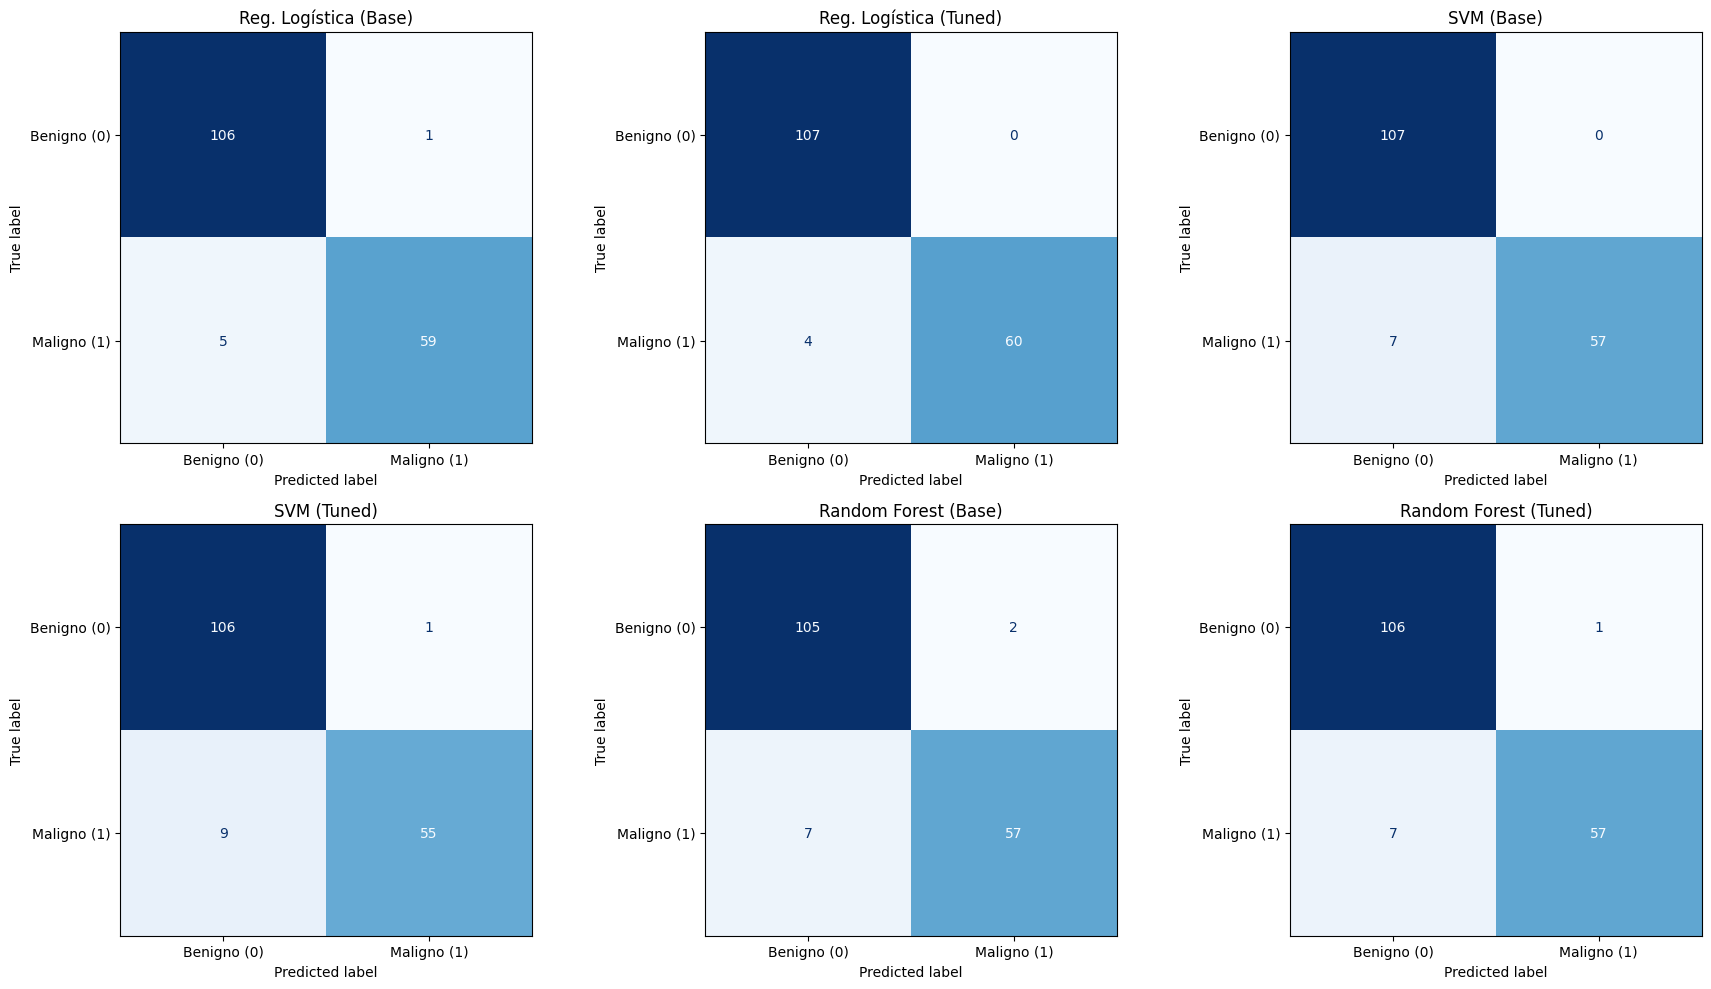


DETALHAMENTO DOS RELATÓRIOS DE CLASSIFICAÇÃO (BASE VS TUNED)

TABELA COMPARATIVA DETALHADA (Ordenada por Recall Maligno):


,Modelo,Acc (Treino),Acc (Teste),Rec. Maligno,F1 Maligno,Prec. Maligno,Rec. Benigno
1,Reg. Logística (Tuned),0.962,0.977,0.938,0.968,1.000,1.000
0,Reg. Logística (Base),0.952,0.965,0.922,0.952,0.983,0.991
2,SVM (Base),0.960,0.959,0.891,0.942,1.000,1.000
4,Random Forest (Base),1.000,0.947,0.891,0.927,0.966,0.981
5,Random Forest (Tuned),1.000,0.953,0.891,0.934,0.983,0.991
3,SVM (Tuned),0.945,0.942,0.859,0.917,0.982,0.991


In [ ]:


# Lista de tuplas com os nomes e os modelos 6 modelos (Base e Tunados)
modelos_list = [
    ("Reg. Logística (Base)", log_reg, X_test_scaled),
    ("Reg. Logística (Tuned)", log_reg_tuned, X_test_scaled),
    ("SVM (Base)", svm_model, X_test_scaled),
    ("SVM (Tuned)", svm_model_tuned, X_test_scaled),
    ("Random Forest (Base)", rf_model, X_test_scaled),
    ("Random Forest (Tuned)", rf_model_tuned, X_test_scaled)
]

target_names = ['Benigno (0)', 'Maligno (1)']

# 1. Visualização em Grade (Matrizes de Confusão)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Facilita a iteração sobre os eixos

for i, (nome, modelo, X_te) in enumerate(modelos_list):
    y_pred = modelo.predict(X_te)
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap='Blues', ax=axes[i], colorbar=False)
    axes[i].set_title(f'{nome}')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

# 2. Detalhamento Estatístico Tabela Comparativa
print("\n" + "="*60)
print("DETALHAMENTO DOS RELATÓRIOS DE CLASSIFICAÇÃO (BASE VS TUNED)")
print("="*60)

tabela_dados = []

for nome, modelo, X_te in modelos_list:
    # Predições para o teste
    y_pred = modelo.predict(X_te)
    report = classification_report(y_test, y_pred, output_dict=True)

    # Cálculo da acurácia de treino para comparar estabilidade
    acc_treino = modelo.score(X_train_scaled, y_train)

    tabela_dados.append({
        'Modelo': nome,
        'Acc (Treino)': f"{acc_treino:.3f}", # Nova coluna para verificar overfitting
        'Acc (Teste)': f"{report['accuracy']:.3f}",
        'Rec. Maligno': f"{report['1']['recall']:.3f}",
        'F1 Maligno': f"{report['1']['f1-score']:.3f}",
        'Prec. Maligno': f"{report['1']['precision']:.3f}",
        'Rec. Benigno': f"{report['0']['recall']:.3f}"
    })

# Cria o DataFrame
df_final = pd.DataFrame(tabela_dados)

# Ordenação pelo Recall Maligno (prioridade para saúde)
print("\nTABELA COMPARATIVA DETALHADA (Ordenada por Recall Maligno):")
display(df_final.sort_values(by='Rec. Maligno', ascending=False))

In [26]:
acc_treino = log_reg_tuned.score(X_train_scaled, y_train)
acc_teste = log_reg_tuned.score(X_test_scaled, y_test)

print(f"Acurácia Treino: {acc_treino:.3f}")
print(f"Acurácia Teste: {acc_teste:.3f}")

Acurácia Treino: 0.962
Acurácia Teste: 0.977


### Análise Comparativa de Desempenho dos Modelos

Abaixo, apresentamos a comparação quantitativa entre os modelos **Regressão Logística**, **SVM (Linear)** e **Random Forest**. Para uma avaliação fiel à natureza crítica do diagnóstico de saúde, utilizamos três pilares de desempenho:

*   **Acurácia (Acc Teste):** Indica a eficiência global do modelo em classificar corretamente tanto casos benignos quanto malignos.
*   **Recall Maligno (Sensibilidade):** É a métrica mais vital para este projeto. Ela mede a capacidade do modelo de identificar corretamente todos os pacientes que realmente possuem a doença, minimizando os "Falsos Negativos" que poderiam atrasar tratamentos críticos.
*   **F1-Score Maligno:** Representa a média harmônica entre a precisão e o recall para a classe maligna, servindo como um indicador de equilíbrio e estabilidade do algoritmo[.

> **Nota Técnica:** Embora o SVM e a Regressão Logística apresentem acurácias globais similares, a escolha do melhor modelo deve priorizar aquele que apresenta o maior Recall, garantindo maior segurança clínica no diagnóstico preventivo.

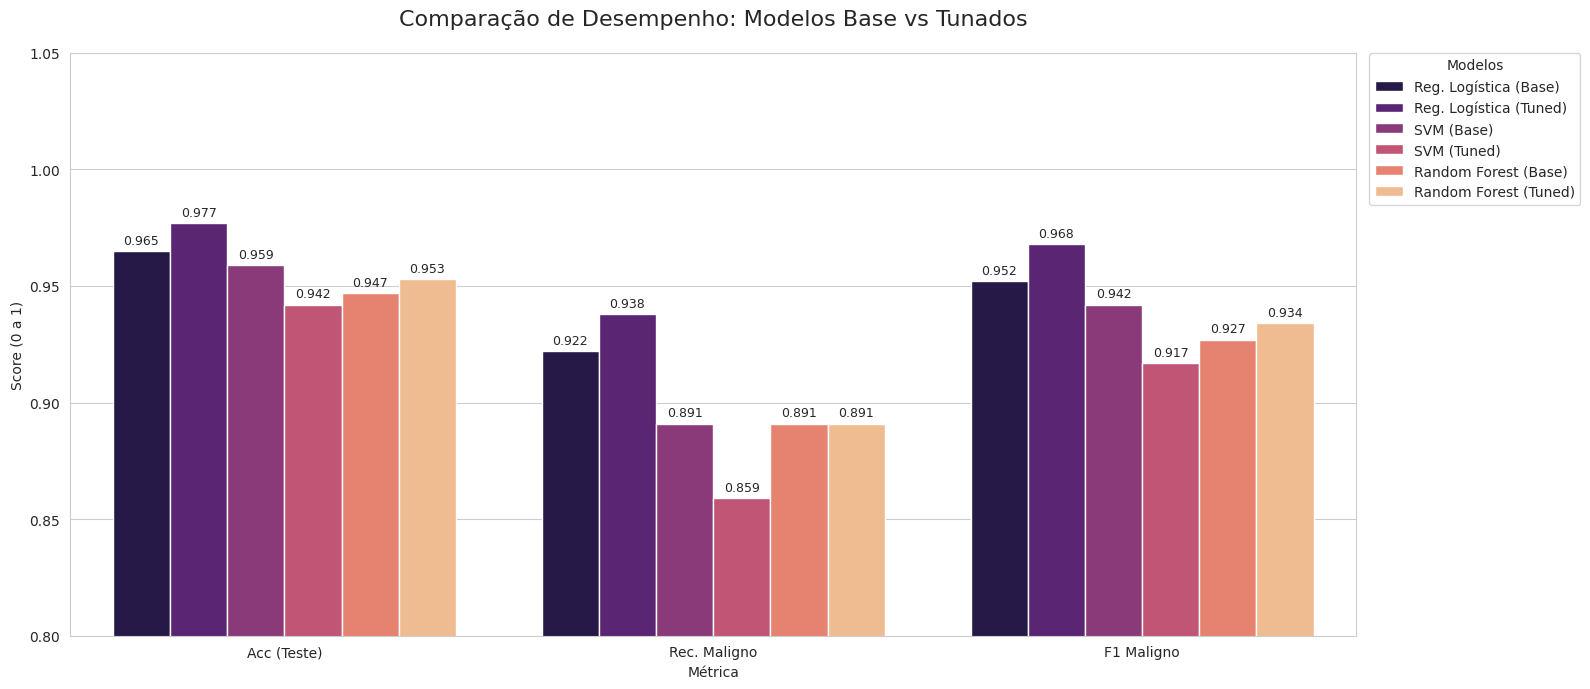

In [27]:


# 1. Preparando os dados (convertendo de string para float com segurança)
df_plot = df_final.copy()
colunas_num = ['Acc (Teste)', 'Rec. Maligno', 'F1 Maligno']

for col in colunas_num:
    df_plot[col] = pd.to_numeric(df_plot[col])

# 2. Transformando para o formato longo
df_melted = df_plot.melt(id_vars='Modelo', value_vars=colunas_num,
                         var_name='Métrica', value_name='Valor')

# 3. Criando o gráfico
plt.figure(figsize=(16, 7))
sns.set_style("whitegrid")

# Paleta 'magma'
grafico = sns.barplot(data=df_melted, x='Métrica', y='Valor', hue='Modelo', palette='magma')

# Valores em cima das barras
for container in grafico.containers:
    grafico.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.title('Comparação de Desempenho: Modelos Base vs Tunados', fontsize=16, pad=20)
plt.ylim(0.8, 1.05)
plt.ylabel('Score (0 a 1)')
# Colocando a legenda para fora para não tampar as barras
plt.legend(title='Modelos', bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

# 5. Análise dos Resultados

Nesta etapa final, avaliamos o impacto da otimização de hiperparâmetros (Tuning) nos modelos **Regressão Logística**, **SVM** e **Random Forest** para a classificação de tumores mamários.

#### **Qual modelo apresentou melhor desempenho?**
O modelo **Regressão Logística (Tuned)** foi o vencedor absoluto. Após a aplicação do **ElasticNet** (via GridSearchCV), ele não apenas manteve a liderança, como elevou o patamar de desempenho em comparação à versão base:
* **Acurácia:** Subiu de 0.965 para **0.977**.
* **Recall Maligno (Sensibilidade):** Aumentou de 0.922 para **0.938**, garantindo maior segurança na detecção de casos críticos.
* **Precisão Maligna:** Alcançou a marca perfeita de **1.000**, eliminando falsos alarmes para diagnósticos positivos.

#### **Quais métricas são mais relevantes nesse contexto?**
Para diagnósticos oncológicos, a hierarquia de métricas foi respeitada:
* **Recall (Sensibilidade) da classe Maligna:** Priorizado como a métrica vital para minimizar falsos negativos e garantir que nenhum tumor maligno passe sem diagnóstico.
* **F1-Score:** Essencial para validar o equilíbrio do modelo, atingindo **0.968** na versão vencedora.
* **Acurácia:** Utilizada para medir a eficiência geral do sistema em ambos os casos (benignos e malignos).

#### **Quais limitações podem existir no modelo desenvolvido?**
Apesar do alto desempenho, é necessário considerar:
* **Generalização:** O dataset original é limitado em volume, o que exige cautela ao aplicar o modelo em populações muito distintas.
* **Trade-off de Tuning:** Observou-se que modelos como o **SVM (Tuned)** podem perder sensibilidade se os parâmetros forem ajustados excessivamente para acurácia geral, reforçando a importância da escolha do scoring correto.
* **Dependência Tecnológica:** A alta performance depende estritamente da padronização de dados (`StandardScaler`) e da manutenção da precisão dos sensores que coletam as características dos tumores.